# Customer Churn Prediction using Explainable AI

## Notebook 04: Exploratory Data Analysis

## Project Overview

Exploratory Data Analysis (EDA) is performed to understand the characteristics, patterns, and relationships present in the customer churn dataset.

In this notebook, customer demographics, tenure, subscribed services, contract information, payment methods, and billing behavior will be analyzed.

The main goal is to identify patterns and factors that may be associated with customer churn. These findings will help guide the machine learning stage and support the development of meaningful business recommendations.

## Objectives

The objectives of this notebook are to:

- Understand the distribution of customer churn.
- Analyze customer demographic characteristics.
- Analyze customer tenure and churn behavior.
- Investigate the relationship between subscribed services and churn.
- Analyze contract types and their relationship with churn.
- Analyze payment methods and churn.
- Examine monthly and total charges.
- Analyze the engineered features.
- Identify important patterns associated with customer churn.
- Generate initial business insights.

## Importing Required Libraries:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",None)

## Load Dataset

The feature-engineered dataset created in the previous notebook is loaded for exploratory data analysis.

In [ ]:
file_path = "/content/Featured_telco_churn.csv"
df = pd.read_csv(file_path)
#print(df.head())
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    7043 non-null   object 
 1   Senior Citizen            7043 non-null   object 
 2   Partner                   7043 non-null   object 
 3   Dependents                7043 non-null   object 
 4   Tenure Months             7043 non-null   int64  
 5   Phone Service             7043 non-null   object 
 6   Multiple Lines            7043 non-null   object 
 7   Internet Service          7043 non-null   object 
 8   Online Security           7043 non-null   object 
 9   Online Backup             7043 non-null   object 
 10  Device Protection         7043 non-null   object 
 11  Tech Support              7043 non-null   object 
 12  Streaming TV              7043 non-null   object 
 13  Streaming Movies          7043 non-null   object 
 14  Contract

## Dataset Verification

Before beginning the analysis, the dataset is checked to confirm its structure, data types, and missing values.

In [ ]:
#print(df.info())
#print(df.dtypes)
#print(df.isnull().sum())
print(df.duplicated().sum())

0


## Customer Churn Distribution

The `Churn Value` variable represents whether a customer left the company.

- 0 represents customers who remained with the company.
- 1 represents customers who churned.

Understanding the distribution of the target variable is important because it provides a baseline view of the company's customer retention situation.

In [ ]:
print(df["Churn Value"].value_counts())
# Percentage:
print(df["Churn Value"].value_counts(normalize = True)*100)

Churn Value
0    5174
1    1869
Name: count, dtype: int64
Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## Visualization:

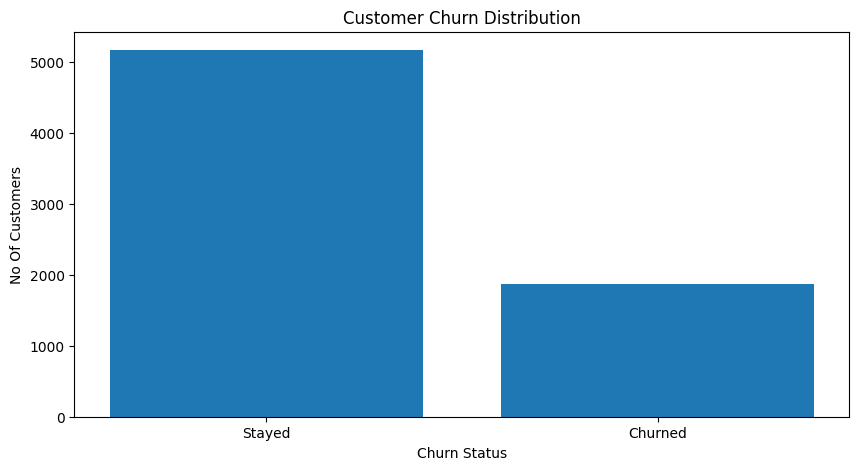

In [ ]:
plt.figure(figsize = (10,5))
plt.bar(
    df["Churn Value"].value_counts().index,
    df["Churn Value"].value_counts().values
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("No Of Customers")
plt.xticks([0,1],["Stayed","Churned"])
plt.show()


## Observation

The majority of customers remained with the company, while a smaller proportion of customers churned.

This indicates that the target variable is imbalanced, with more customers staying than leaving.

In [ ]:
churn_rate  = df["Churn Value"].mean()
print(f"Churn Rate: {churn_rate*100:.2f}%")

Churn Rate: 26.54%


## Business Interpretation

The overall churn rate provides a baseline against which different customer groups can be compared.

Customer segments with churn rates substantially higher than the overall churn rate may require additional attention from the business.

#Demographic Analysis
## Churn by Gender
- `crosstab()` is used to compare two caategorical features and calculate their percentages.

This analysis compares customer churn rates between male and female customers to determine whether gender appears to be associated with churn.

In [ ]:
print(pd.crosstab(
    df["Gender"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value          0          1
Gender                           
Female       73.079128  26.920872
Male         73.839662  26.160338


## Visualization:

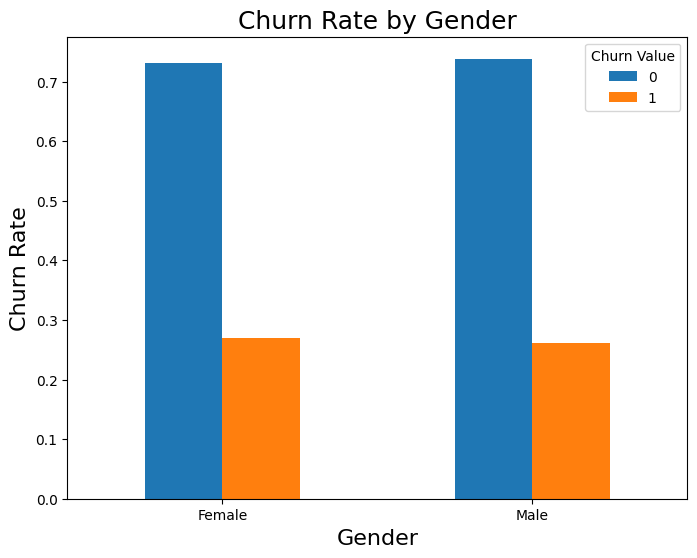

In [ ]:
pd.crosstab(
    df["Gender"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (8,6))
plt.title("Churn Rate by Gender",fontsize = 18)
plt.xlabel("Gender",fontsize  = 16)
plt.ylabel("Churn Rate",fontsize = 16)
plt.xticks(rotation = 0)
plt.show()

## Senior Citizen vs Churn:

In [ ]:
print(pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value             0          1
Senior Citizen                      
No              76.393832  23.606168
Yes             58.318739  41.681261


## Visualization:

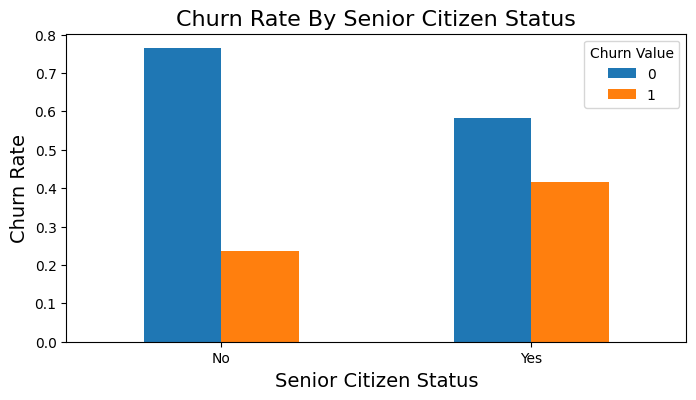

In [ ]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Senior Citizen Status",fontsize = 16)
plt.xlabel("Senior Citizen Status",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Partner vs Churn:

In [ ]:
print(
    pd.crosstab(
        df["Partner"],
        df["Churn Value"],
        normalize = "index"
    )*100
)

Churn Value          0          1
Partner                          
No           67.042021  32.957979
Yes          80.335097  19.664903


## Visualization:

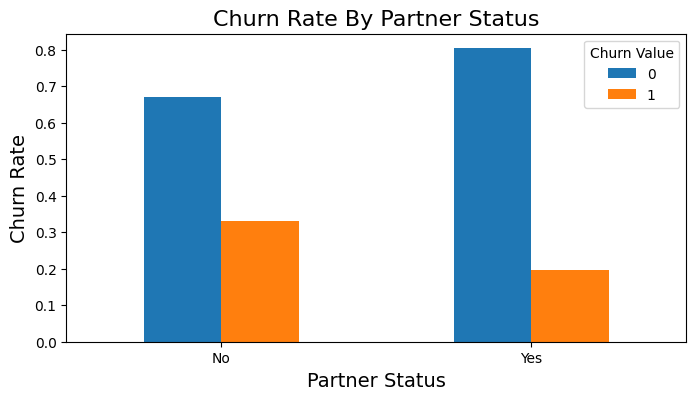

In [ ]:
pd.crosstab(
        df["Partner"],
        df["Churn Value"],
        normalize = "index"
    ).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Partner Status",fontsize = 16)
plt.xlabel("Partner Status",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Dependents vs Churn:

In [ ]:
print(pd.crosstab(
    df["Dependents"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value          0          1
Dependents                       
No           67.448301  32.551699
Yes          93.484942   6.515058


## Visualization:

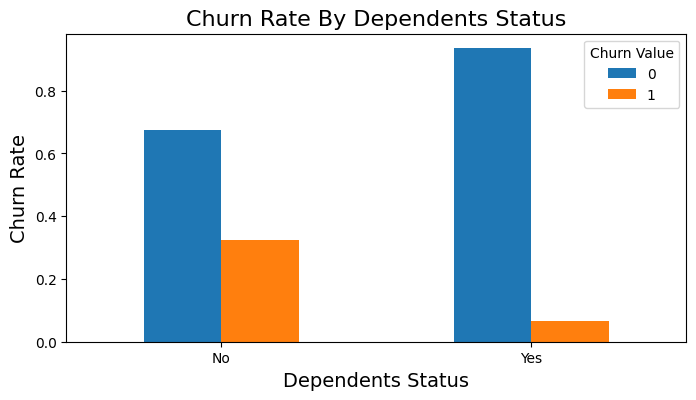

In [ ]:
pd.crosstab(
    df["Dependents"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Dependents Status",fontsize = 16)
plt.xlabel("Dependents Status",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Customer Tenure Analysis

Customer tenure represents the number of months a customer has remained with the company.

Analyzing tenure helps determine whether newer customers or long-term customers are more likely to churn.

In [ ]:
print(df["Tenure Months"].describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64


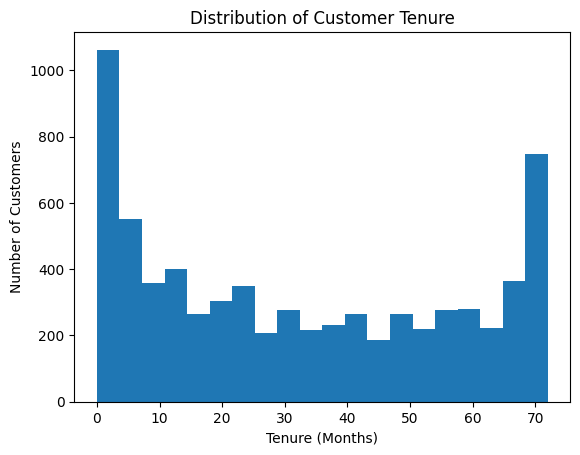

In [ ]:
plt.hist(df["Tenure Months"], bins=20)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

## Tenure Group vs Churn:

In [ ]:
print(pd.crosstab(
    df["Tenure Group"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value           0          1
Tenure Group                      
Early         71.289062  28.710938
Established   79.611041  20.388959
Long-term     90.486824   9.513176
New           52.561757  47.438243


## Visualization:

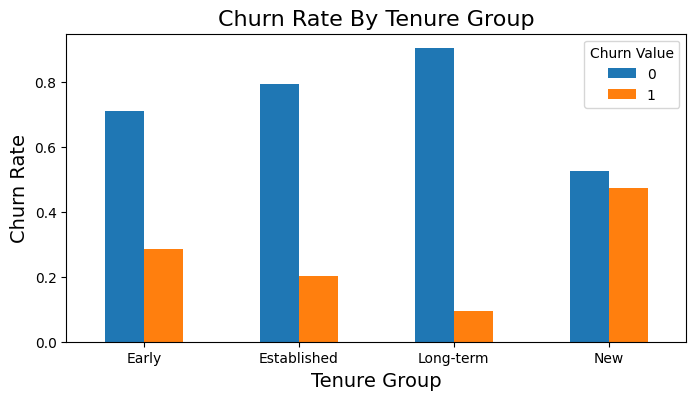

In [ ]:
pd.crosstab(
    df["Tenure Group"],
    df["Churn Value"],
 normalize = "index"
).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Tenure Group",fontsize = 16)
plt.xlabel("Tenure Group",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Churn by Contract Type

Contract type may influence customer retention because longer contracts can create stronger customer commitment.

The churn rate for each contract type is compared to identify potential differences in customer retention.

In [ ]:
#print(df["Contract"].value_counts())
print(pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value             0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


## Visualization:

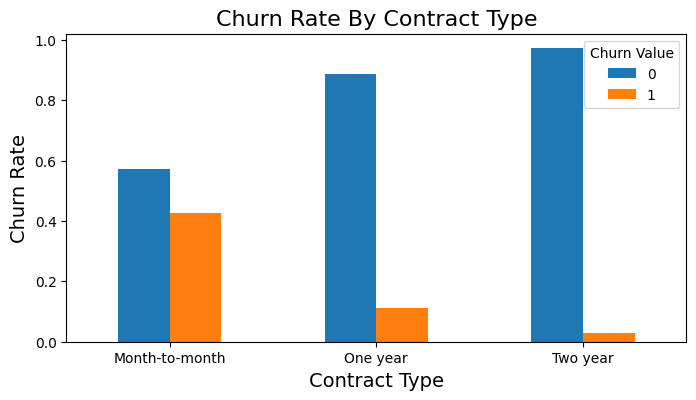

In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Contract Type",fontsize = 16)
plt.xlabel("Contract Type",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Internet Service vs Churn:

In [ ]:
print(
    pd.crosstab(
        df["Internet Service"],
        df["Churn Value"],
        normalize = "index"
    )*100)

Churn Value               0          1
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


## Visualization:

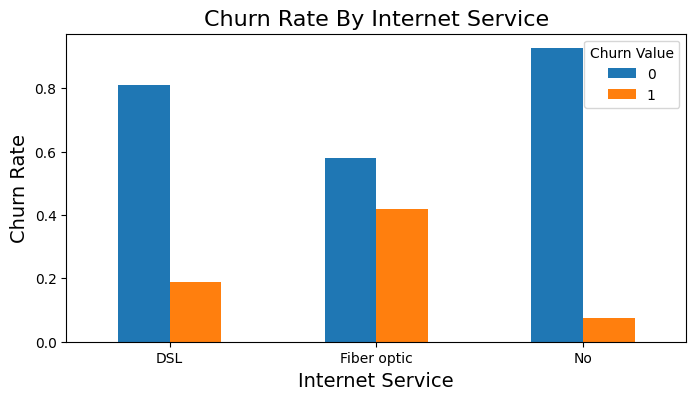

In [ ]:
pd.crosstab(
        df["Internet Service"],
        df["Churn Value"],
        normalize = "index"
    ).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Internet Service",fontsize = 16)
plt.xlabel("Internet Service",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Payment Method vs Churn:

In [ ]:
print(pd.crosstab(
    df["Payment Method"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value                        0          1
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


## Visualization:

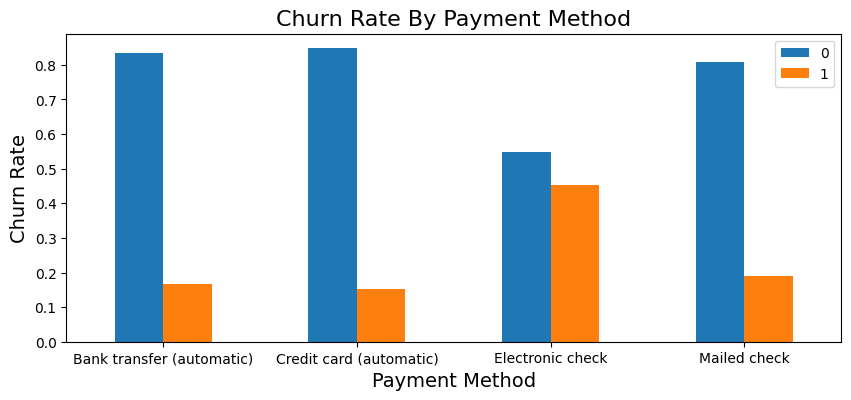

In [ ]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (10,4))
plt.title("Churn Rate By Payment Method",fontsize = 16)
plt.xlabel("Payment Method",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.legend(loc = "upper right")
plt.show()

## Monthly Charges and Churn

Monthly Charges represents the customer's current monthly billing amount.

The mean and median monthly charges are compared between churned and retained customers to identify potential differences in billing behavior.

In [ ]:
print(df.groupby(["Churn Value"])["Monthly Charges"].mean())
print(df.groupby(["Churn Value"])["Monthly Charges"].median())

Churn Value
0    61.265124
1    74.441332
Name: Monthly Charges, dtype: float64
Churn Value
0    64.425
1    79.650
Name: Monthly Charges, dtype: float64


## Visualization:

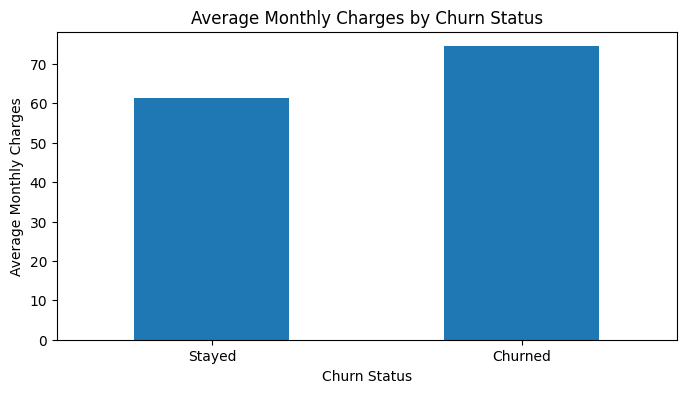

In [ ]:
df.groupby(["Churn Value"])["Monthly Charges"].mean().plot(kind="bar",figsize=(8,4))
plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)

plt.show()

## Total Charges and Churn

Total Charges represents the total amount charged to the customer during their relationship with the company.

The mean and median values are compared between churned and retained customers.

In [ ]:
print(df.groupby(["Churn Value"])["Total Charges"].mean())
print(df.groupby(["Churn Value"])["Total Charges"].median())

Churn Value
0    2549.911442
1    1531.796094
Name: Total Charges, dtype: float64
Churn Value
0    1679.525
1     703.550
Name: Total Charges, dtype: float64


## Visualization:

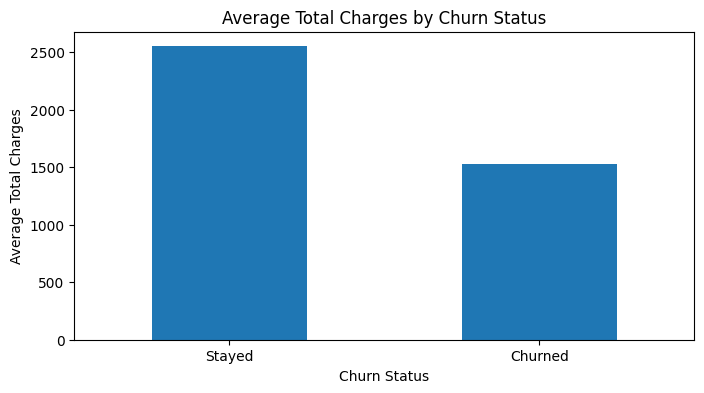

In [ ]:
df.groupby(["Churn Value"])["Total Charges"].mean().plot(kind="bar",figsize=(8,4))
plt.title("Average Total Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Total Charges")
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)
plt.show()

# Engineered Features vs Churn:

## We created these features in Notebook 03:

- `Total Additional Services`
- `Total Streaming Services`
- `Total Security Services`
- `Has Multiple Services`

These are counts/categories, so crosstab makes sense.

## Total Additional Services:

In [ ]:
print(df["Total Aditional Services"].value_counts().sort_index())

Total Aditional Services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


In [ ]:
print(
    pd.crosstab(
    df["Total Aditional Services"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value                       0          1
Total Aditional Services                      
0                         78.593961  21.406039
1                         54.244306  45.755694
2                         64.181994  35.818006
3                         72.629696  27.370304
4                         77.699531  22.300469
5                         87.565674  12.434326
6                         94.718310   5.281690


## Visualization:

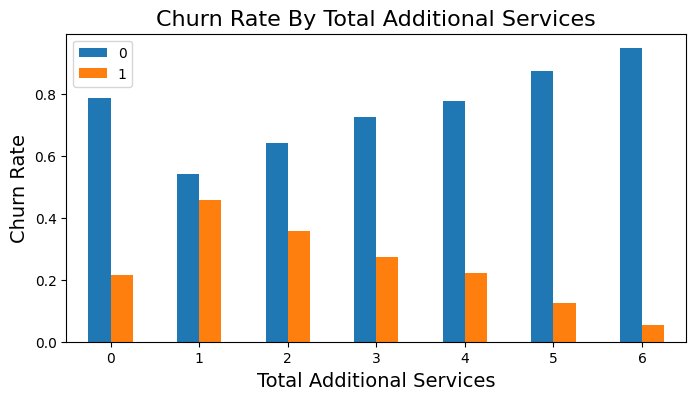

In [ ]:
pd.crosstab(
    df["Total Aditional Services"],
    df["Churn Value"],
    normalize = "index"
).plot(kind  = "bar",figsize = (8,4))
plt.title("Churn Rate By Total Additional Services",fontsize = 16)
plt.xlabel("Total Additional Services",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.legend(loc = "upper left")
plt.show()

##  Total Streaming Services vs Churn:

In [ ]:
print(pd.crosstab(
    df["Total Streaming Services"],
    df["Churn Value"],
    normalize = "index"
)*100)

Churn Value                       0          1
Total Streaming Services                      
0                         77.200903  22.799097
1                         68.569596  31.430404
2                         70.567010  29.432990


## Visualization:

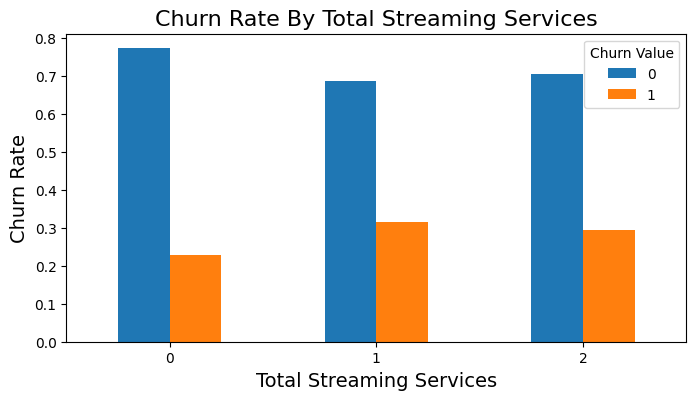

In [ ]:
pd.crosstab(
    df["Total Streaming Services"],
    df["Churn Value"],
    normalize = "index"
).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By Total Streaming Services",fontsize = 16)
plt.xlabel("Total Streaming Services",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Total Security Services vs Churn:

In [ ]:
print(
    pd.crosstab(
        df["Total Security Services"],
        df["Churn Value"],
        normalize = "index"
    )*100)

Churn Value                      0          1
Total Security Services                      
0                        70.148270  29.851730
1                        66.394780  33.605220
2                        80.352304  19.647696
3                        92.063492   7.936508


## Visualization:

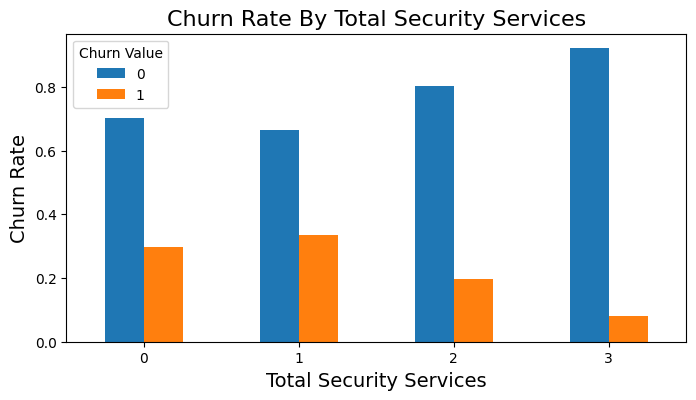

In [ ]:
pd.crosstab(
        df["Total Security Services"],
        df["Churn Value"],
        normalize = "index"
    ).plot(kind  = "bar",figsize = (8,4))
plt.title("Churn Rate By Total Security Services",fontsize = 16)
plt.xlabel("Total Security Services",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Has Multiple Services vs Churn:

In [ ]:
print(
    pd.crosstab(
        df["Has Multiple Services"],
        df["Churn Value"],
        normalize = "index"
    )*100)

Churn Value                    0          1
Has Multiple Services                      
0                      71.208791  28.791209
1                      75.324002  24.675998


## Visualization:

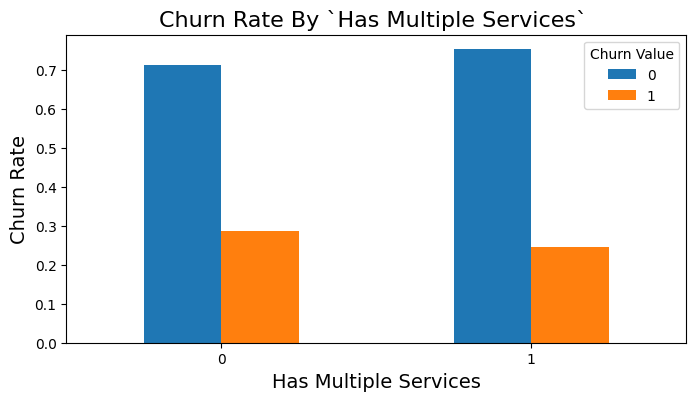

In [ ]:
pd.crosstab(
        df["Has Multiple Services"],
        df["Churn Value"],
        normalize = "index"
    ).plot(kind = "bar",figsize = (8,4))
plt.title("Churn Rate By `Has Multiple Services` ",fontsize = 16)
plt.xlabel("Has Multiple Services",fontsize  = 14)
plt.ylabel("Churn Rate",fontsize = 14)
plt.xticks(rotation = 0)
plt.show()

## Correlation Analysis

Correlation analysis is used to examine the relationships among important numerical variables.

This analysis helps identify variables that may have stronger relationships with the churn target and with each other.

Correlation indicates association, not causation.

In [ ]:
numeric_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value",
    "Total Aditional Services",
    "Total Streaming Services",
    "Total Security Services",
    "Has Multiple Services"
]

correlation = df[numeric_columns].corr()

print(correlation)

                          Tenure Months  Monthly Charges  Total Charges  \
Tenure Months                  1.000000         0.247900       0.826178   
Monthly Charges                0.247900         1.000000       0.651174   
Total Charges                  0.826178         0.651174       1.000000   
CLTV                           0.396406         0.098693       0.342091   
Churn Value                   -0.352229         0.193356      -0.198324   
Total Aditional Services       0.494263         0.724706       0.744827   
Total Streaming Services       0.323161         0.717871       0.591130   
Total Security Services        0.482515         0.564031       0.665105   
Has Multiple Services          0.386367         0.665156       0.597015   

                              CLTV  Churn Value  Total Aditional Services  \
Tenure Months             0.396406    -0.352229                  0.494263   
Monthly Charges           0.098693     0.193356                  0.724706   
Total Charges     

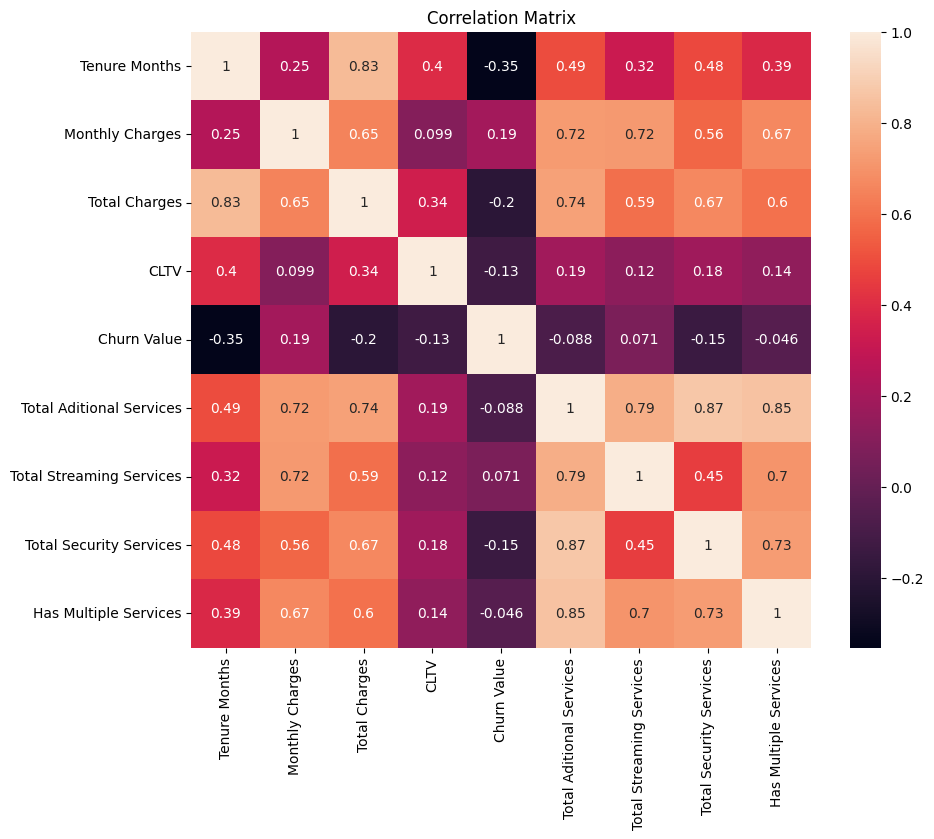

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Key EDA Findings

The exploratory analysis revealed several important patterns associated with customer churn:

- The overall churn rate is **26.54%**, with 1,869 out of 7,043 customers having churned.

- **Customer tenure is strongly associated with churn.** New customers show substantially higher churn than long-term customers. The churn rate decreases considerably as customer tenure increases.

- **Contract type shows a strong relationship with churn.** Month-to-month customers have the highest churn rate, while customers with two-year contracts have the lowest churn rate.

- **Internet service type shows noticeable differences in churn.** Fiber optic customers have a considerably higher churn rate than DSL and customers without internet service.

- **Payment method is strongly associated with churn.** Customers using electronic check have substantially higher churn than customers using automatic bank transfer or automatic credit card payments.

- **Senior citizens have a higher churn rate** than non-senior customers.

- Customers **without partners or dependents** show higher churn rates than customers with partners or dependents.

- **Gender shows very little difference in churn**, suggesting that it is not a major differentiating factor in this dataset.

- **Churned customers have higher monthly charges on average** than retained customers.

- **Churned customers have lower total charges** than retained customers, which is consistent with their generally shorter tenure.

- The engineered service-count features show that customer engagement with additional services is associated with different churn patterns, although these relationships are not always linear.

- Among the numerical variables, **Tenure Months shows a negative relationship with churn**, while **Monthly Charges shows a positive relationship with churn**.

These findings identify several potentially important predictors that will be investigated further during the machine learning stage.

## Conclusion

Exploratory Data Analysis provided an understanding of the main patterns associated with customer churn.

The analysis indicates that customer tenure, contract type, internet service, payment method, monthly charges, and selected demographic characteristics show meaningful differences between churned and retained customers.

These findings will guide the preparation of the final modeling dataset and help identify potentially important variables for the predictive models.

However, the observed relationships represent associations within the dataset and do not establish causation. Machine learning models will therefore be used in the next stage to evaluate how effectively these variables can predict customer churn.

The next phase of the project will focus on preparing the data for machine learning and building baseline predictive models.